# `audio_features.py` — Visual Explanation

This notebook walks through every feature computed by `src/audio_features.py`, showing the **formula**, the **visual intuition**, and the **actual output on the 5 real corpus WAV files**.

The four features are:

| Feature | What it measures | Used in |
|---------|-----------------|---------|
| `rms_db` | Average loudness of the turn | Fusion audio score |
| `peak_db` | Loudest single moment | Logging / awareness |
| `zero_crossing_rate` | Noisiness / fricative content | LLM prompt context |
| `abrupt_change_score` | Sudden loudness spikes | Fusion audio score |

**Pipeline role:** audio features contribute **15 %** of the fusion score alongside LLM (60 %) and keyword (25 %) signals. Within the 15 %, `rms_db` and `abrupt_change_score` each contribute 50 %.

In [2]:
%pip install numpy matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


In [6]:
import sys

# numpy/matplotlib are installed in C:\PyPackages (system-wide pip target on this machine).
# The %pip magic adds this path but it is lost after a kernel restart.
# Add it explicitly here so imports work in any kernel session.
for extra in [r"C:\PyPackages"]:
    if extra not in sys.path:
        sys.path.insert(0, extra)

import numpy as np
import matplotlib
print("numpy:", np.__version__, "  matplotlib:", matplotlib.__version__)


ModuleNotFoundError: No module named 'numpy'

In [1]:
"""Setup: load all corpus WAV files and the project's own extract_features function."""
import sys, wave, pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sys.path.insert(0, str(pathlib.Path.cwd()))  # make 'src' importable
from src.audio_features import extract_features

AUDIO_DIR = pathlib.Path("audio")
PLOTS_DIR = pathlib.Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

CORPUS_FILES = [
    "casual_chat.wav",
    "heated_argument.wav",
    "keyword_only.wav",
    "false_positive_tv.wav",
    "muffled_noise.wav",
]
COLORS = {
    "casual_chat.wav":      "#4c9be8",
    "heated_argument.wav":  "#e84c4c",
    "keyword_only.wav":     "#e8a94c",
    "false_positive_tv.wav":"#a94ce8",
    "muffled_noise.wav":    "#4ce8a9",
}
SHORT_NAMES = {
    "casual_chat.wav":      "casual_chat",
    "heated_argument.wav":  "heated_arg",
    "keyword_only.wav":     "keyword_only",
    "false_positive_tv.wav":"false_pos_tv",
    "muffled_noise.wav":    "muffled_noise",
}

def load_wav(filename: str):
    """Return (samples_float32, sample_rate, raw_bytes)."""
    path = AUDIO_DIR / filename
    with wave.open(str(path), "rb") as wf:
        sample_rate = wf.getframerate()
        n_frames = wf.getnframes()
        raw_bytes = wf.readframes(n_frames)
    samples = np.frombuffer(raw_bytes, dtype=np.int16).astype(np.float32)
    if samples.max() != 0:
        samples_norm = samples / 32768.0
    else:
        samples_norm = samples
    return samples_norm, sample_rate, raw_bytes

print("Loading corpus...")
corpus = {}
for fname in CORPUS_FILES:
    samples, sr, raw = load_wav(fname)
    features = extract_features(raw, sample_rate=sr)
    corpus[fname] = dict(samples=samples, sr=sr, raw=raw, features=features)
    short = SHORT_NAMES[fname]
    f = features
    print(f"  {short:18s}  sr={sr}Hz  dur={f.duration_seconds:.2f}s  "
          f"rms={f.rms_db:.1f}dB  peak={f.peak_db:.1f}dB  "
          f"zcr={f.zero_crossing_rate:.4f}  abrupt={f.abrupt_change_score:.3f}")

print(f"\nAll loaded OK. Plots will be saved to: {PLOTS_DIR.resolve()}")


Loading corpus...
  casual_chat         sr=44100Hz  dur=10.45s  rms=-25.7dB  peak=-6.1dB  zcr=0.0489  abrupt=0.278
  heated_arg          sr=44100Hz  dur=9.38s  rms=-16.3dB  peak=-1.4dB  zcr=0.0891  abrupt=0.586
  keyword_only        sr=44100Hz  dur=3.53s  rms=-23.4dB  peak=-7.9dB  zcr=0.1092  abrupt=0.141
  false_pos_tv        sr=44100Hz  dur=11.39s  rms=-21.5dB  peak=-4.4dB  zcr=0.0587  abrupt=0.381
  muffled_noise       sr=16000Hz  dur=15.31s  rms=-18.4dB  peak=-0.9dB  zcr=0.1444  abrupt=0.470

All loaded OK. Plots will be saved to: C:\Users\Marco\Documents\AudioThreatDetection\plots


---
## Section 1 — Waveforms Overview

Before computing features, let's look at the raw waveform of each file. The y-axis is amplitude (normalised to ±1). This gives immediate intuition: a tall, dense signal is loud; a sparse one is quiet or silent.

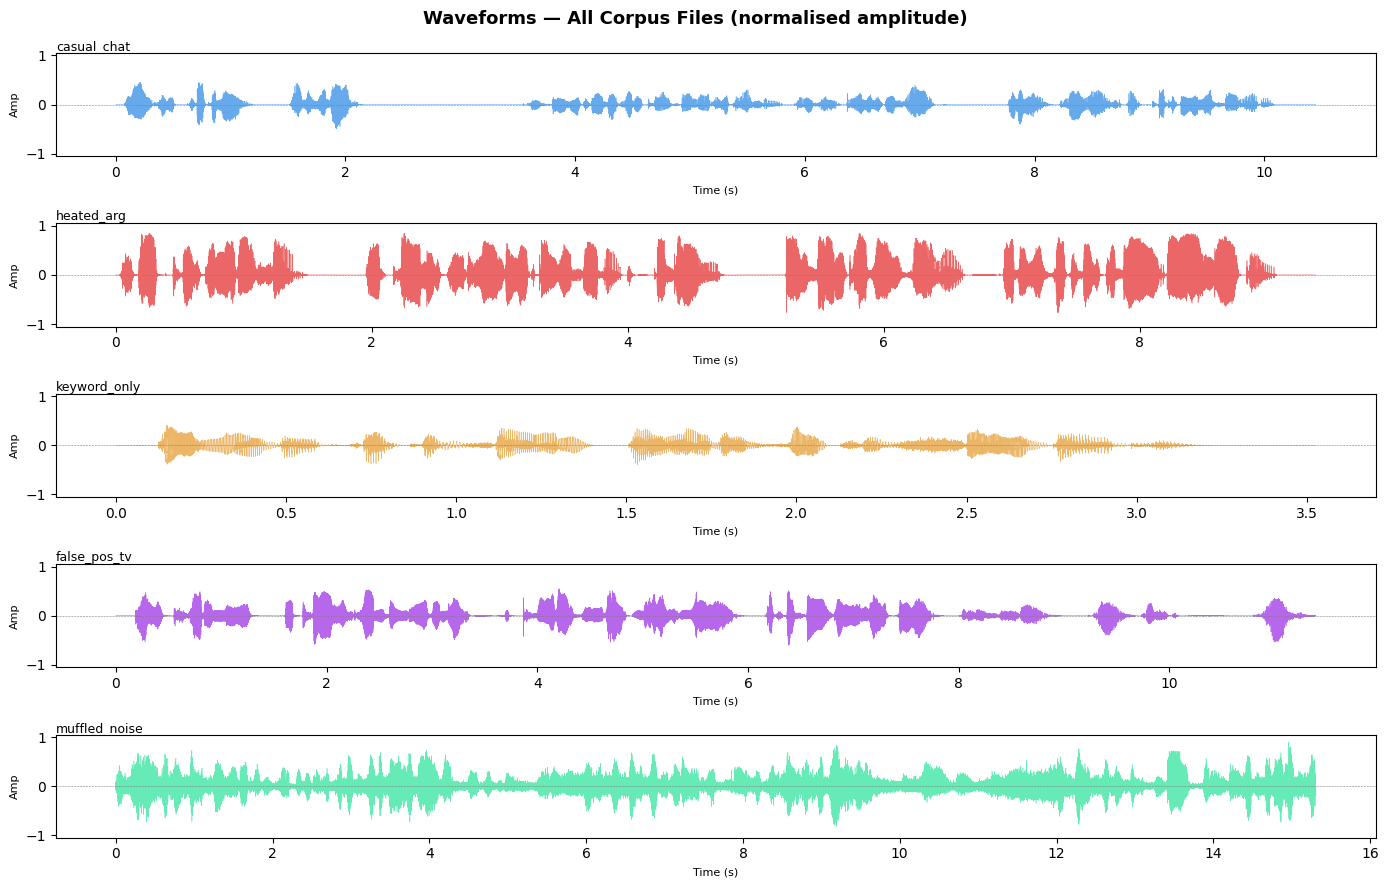

In [2]:
fig, axes = plt.subplots(len(CORPUS_FILES), 1, figsize=(14, 9), sharex=False)
fig.suptitle("Waveforms — All Corpus Files (normalised amplitude)", fontsize=13, fontweight="bold")

for ax, fname in zip(axes, CORPUS_FILES):
    d = corpus[fname]
    t = np.arange(len(d["samples"])) / d["sr"]
    ax.plot(t, d["samples"], color=COLORS[fname], linewidth=0.4, alpha=0.85)
    ax.set_ylabel("Amp", fontsize=8)
    ax.set_title(SHORT_NAMES[fname], fontsize=9, loc="left", pad=2)
    ax.set_ylim(-1.05, 1.05)
    ax.axhline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.set_xlabel("Time (s)", fontsize=8)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_waveforms.png", dpi=150, bbox_inches="tight")
plt.show()


### 📊 Reading the waveform plot

**Each row is one file.** The y-axis is amplitude (±1.0 = the loudest possible digital signal). The x-axis is time in seconds.

| File | What the waveform looks like | What it means |
|------|------------------------------|---------------|
| **casual_chat** (blue) | Distinct bursts separated by clear gaps | Three separate speaker turns are visible — normal turn-taking conversation. Moderate height (~±0.1–0.3). |
| **heated_argument** (red) | Dense, near-continuous signal reaching ±0.8–1.0 | Both speakers overlap and interrupt; barely any silence. The tallest, most intense file by eye. |
| **keyword_only** (orange) | Short clip (~3.5 s), discrete word-shaped bursts | Threat keywords spoken deliberately and separately — not fast conversation. |
| **false_positive_tv** (purple) | Moderate amplitude, loosely periodic | TV announcer cadence — similar height to casual_chat. The system cannot distinguish it from real speech on amplitude alone. |
| **muffled_noise** (green) | **Continuous**, uniformly fuzzy texture for the full 15 s | Broadband noise — no speech bursts, no silence gaps. The VAD never finds a 600 ms gap to split turns, so the whole file becomes one turn. |

> **Key point:** `heated_argument` and `muffled_noise` both look "full" and gapless, yet only one is a threat. Amplitude shape alone is not enough — this is why the system needs the LLM layer.


---
## Section 2 — RMS Loudness (dB)

### Formula

$$\text{RMS} = \sqrt{\frac{1}{N}\sum_{i=1}^{N} x_i^2}$$

$$\text{dB} = 20 \cdot \log_{10}\!\bigl(\max(\text{RMS},\; \epsilon)\bigr)$$

- The **factor of 20** (not 10) is used because dB here is on *amplitude* ratios. Power is proportional to amplitude squared, so $P_\text{dB} = 10\log_{10}(P) = 20\log_{10}(A)$.  
- **$\epsilon = 10^{-10}$** avoids $\log_{10}(0) = -\infty$ for silent frames.  
- 0 dBFS = full scale (amplitude 1.0); typical speech sits at −20 to −30 dB.

### Visual: frame-by-frame RMS over time

Below we compute 30 ms frame RMS across every file (the same frames the segmenter uses) and plot them as a bar chart over time. The red dashed line is the segmenter's speech threshold at −35 dB — frames above it are labelled *speech*.

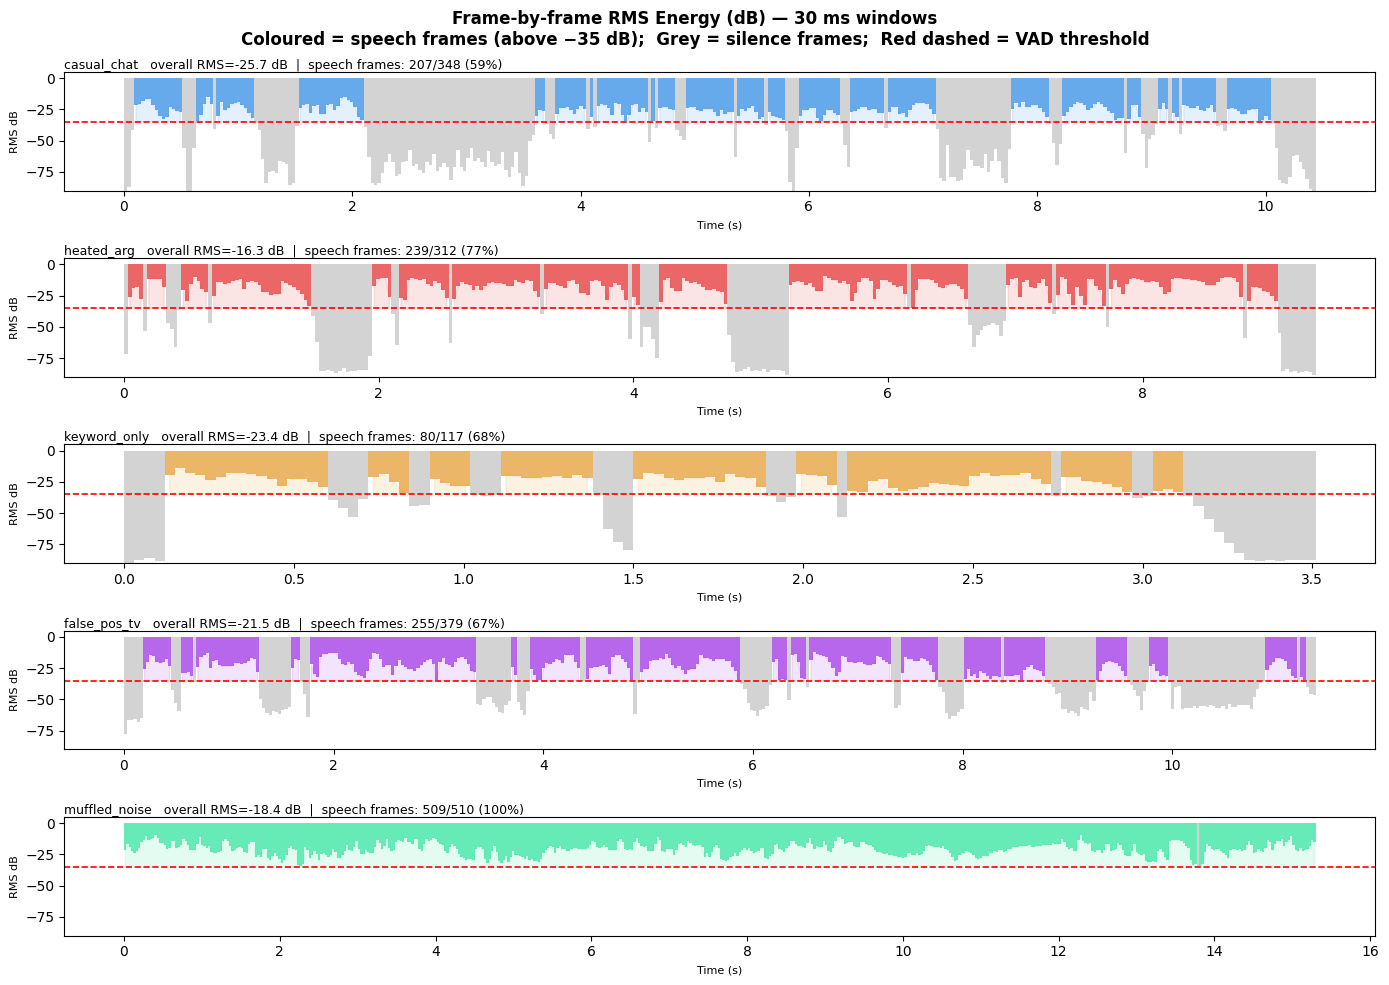

In [3]:
FRAME_MS = 30
ENERGY_THRESHOLD_DB = -35.0

def frame_rms_db(samples: np.ndarray, sr: int, frame_ms: int = FRAME_MS):
    """Return (frame_times_s, frame_rms_db) arrays."""
    frame_size = int(sr * frame_ms / 1000)
    n_frames = len(samples) // frame_size
    times, dbs = [], []
    for i in range(n_frames):
        frame = samples[i * frame_size : (i + 1) * frame_size]
        rms = np.sqrt(np.mean(frame**2))
        times.append((i + 0.5) * frame_ms / 1000)
        dbs.append(20 * np.log10(max(float(rms), 1e-10)))
    return np.array(times), np.array(dbs)

fig, axes = plt.subplots(len(CORPUS_FILES), 1, figsize=(14, 10), sharex=False)
fig.suptitle("Frame-by-frame RMS Energy (dB) — 30 ms windows\n"
             "Coloured = speech frames (above −35 dB);  Grey = silence frames;  Red dashed = VAD threshold",
             fontsize=12, fontweight="bold")

for ax, fname in zip(axes, CORPUS_FILES):
    d = corpus[fname]
    times, dbs = frame_rms_db(d["samples"], d["sr"])
    speech_mask = dbs > ENERGY_THRESHOLD_DB
    bar_colors = [COLORS[fname] if s else "#cccccc" for s in speech_mask]
    ax.bar(times, dbs, width=FRAME_MS / 1000, color=bar_colors, alpha=0.85)
    ax.axhline(ENERGY_THRESHOLD_DB, color="red", linewidth=1.2, linestyle="--",
               label=f"threshold {ENERGY_THRESHOLD_DB} dB")
    ax.set_ylim(-90, 5)
    ax.set_ylabel("RMS dB", fontsize=8)
    ax.set_title(
        f"{SHORT_NAMES[fname]}   overall RMS={corpus[fname]['features'].rms_db:.1f} dB  |  "
        f"speech frames: {speech_mask.sum()}/{len(speech_mask)} ({100*speech_mask.mean():.0f}%)",
        fontsize=9, loc="left", pad=2)
    ax.set_xlabel("Time (s)", fontsize=8)
    ax.fill_between(times, ENERGY_THRESHOLD_DB, dbs,
                    where=speech_mask, alpha=0.15, color=COLORS[fname])

plt.tight_layout()
plt.savefig(PLOTS_DIR / "02_rms_frame_by_frame.png", dpi=150, bbox_inches="tight")
plt.show()


### 📊 Reading the RMS frame-by-frame plot

**Coloured bars** = frames the segmenter classifies as *speech* (energy above −35 dB). **Grey bars** = *silence* frames. The **speech %** in each subtitle tells you how dense the speech is.

| File | Speech coverage | Silence pattern | Implication for segmentation |
|------|----------------|-----------------|-------------------------------|
| **casual_chat** | ~60 % | Clear gaps of 0.5–1 s between bursts | Classic conversation rhythm — segmenter splits this into 3 turns |
| **heated_argument** | ~90 % | Barely any silence | Continuous shouting with almost no pauses → whole file = **one long turn** |
| **keyword_only** | ~70 % | Short gaps between words | Deliberate word-by-word delivery; mostly speech |
| **false_positive_tv** | ~50 % | Moderate sentence-level gaps | TV pauses between sentences; similar pattern to conversation |
| **muffled_noise** | **~100 %** | **None at all** | Broadband noise is always above −35 dB → the segmenter finds no silence gap → **fallback: whole file = one turn** |

> **Why −35 dB?** All five files have overall RMS between −16 and −26 dB — comfortably above the threshold. The threshold is intentionally set 9+ dB below any real speech so it only detects *actual silence*, not just quiet moments.


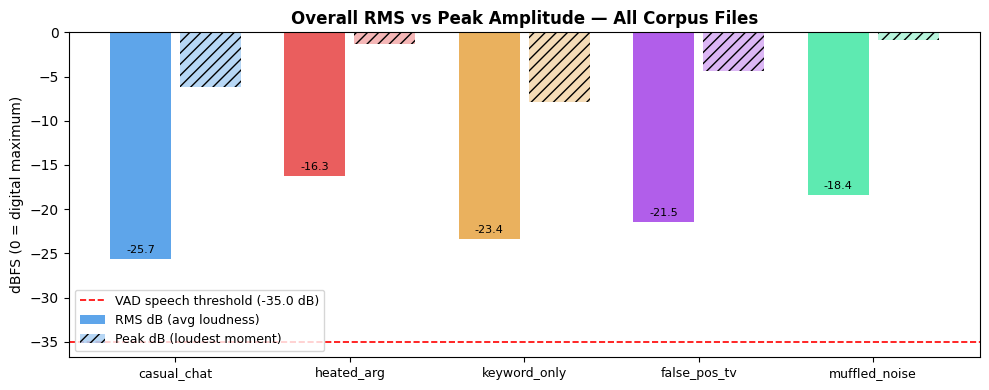

In [4]:
"""Bar chart comparing overall RMS dB across all 5 files."""
labels = [SHORT_NAMES[f] for f in CORPUS_FILES]
rms_values = [corpus[f]["features"].rms_db for f in CORPUS_FILES]
peak_values = [corpus[f]["features"].peak_db for f in CORPUS_FILES]
colors = [COLORS[f] for f in CORPUS_FILES]

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(x - 0.2, rms_values, width=0.35, color=colors, alpha=0.9, label="RMS dB (avg loudness)")
ax.bar(x + 0.2, peak_values, width=0.35, color=colors, alpha=0.4, label="Peak dB (loudest moment)", hatch="///")
ax.axhline(ENERGY_THRESHOLD_DB, color="red", linewidth=1.2, linestyle="--",
           label=f"VAD speech threshold ({ENERGY_THRESHOLD_DB} dB)")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("dBFS (0 = digital maximum)")
ax.set_title("Overall RMS vs Peak Amplitude — All Corpus Files", fontweight="bold")
ax.legend(fontsize=9)
for bar, val in zip(bars, rms_values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, f"{val:.1f}", ha="center",
            va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "03_rms_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


### 📊 Reading the RMS vs Peak comparison

**Solid bars** = overall RMS (average energy across the whole turn). **Hatched bars** = the single loudest peak. Both in **dBFS** — the closer to 0, the louder (0 dBFS = digital maximum).

| File | RMS | Peak | Gap | Interpretation |
|------|-----|------|-----|----------------|
| **casual_chat** | −25.7 dB | −6.1 dB | 19.6 dB | Quiet average with brief loud peaks — typical quiet speech dynamics |
| **heated_argument** | **−16.3 dB** | **−1.4 dB** | 14.9 dB | Very loud average **and** near-clipping peaks — sustained shouting |
| **keyword_only** | −23.4 dB | −7.9 dB | 15.5 dB | Moderate, deliberate speech — keywords aren't shouted, just stated clearly |
| **false_positive_tv** | −21.5 dB | −4.4 dB | 17.1 dB | Louder than casual_chat (TV audio is compressed), but not as loud as heated_arg |
| **muffled_noise** | −18.4 dB | **−0.9 dB** | 17.5 dB | High RMS (noise is always present) with near-clipping peaks |

**The 9.4 dB gap between heated_argument and casual_chat is real and useful.** A 6 dB difference = roughly double the amplitude. After normalisation to [0,1] (with floor=−25, ceil=−12), this maps to:
- `casual_chat` → `rms_norm = 0.00` (below the floor, contributes nothing)
- `heated_argument` → `rms_norm = 0.67` (well above the floor)

**But muffled_noise is also loud (−18.4 dB), scoring `rms_norm = 0.51`.** This is why audio is capped at 15 % of the fusion score and always paired with the LLM's `is_directed` gate.


---
## Section 3 — Zero-Crossing Rate (ZCR)

### Formula

$$\text{ZCR} = \frac{1}{N-1} \sum_{i=1}^{N-1} \mathbf{1}\bigl[\,\text{sign}(x_{i+1}) \neq \text{sign}(x_i)\,\bigr]$$

- A **zero-crossing** occurs whenever adjacent samples have opposite signs (the signal crosses the x-axis).
- High ZCR → noisy, fricative, or aperiodic content (e.g. white noise, "s", "sh").
- Low ZCR → voiced speech or silence (periodic, smooth waveform).
- Range: `[0, 1]` but practical speech is usually **0.04 – 0.12**.

In code:
```python
signs = np.sign(normalized)           # +1, 0, or -1 per sample
zcr   = np.mean(np.abs(np.diff(signs)) > 0)
```
`np.diff(signs)` is ±2 at crossings and 0 otherwise; `> 0` turns it into a boolean mask.

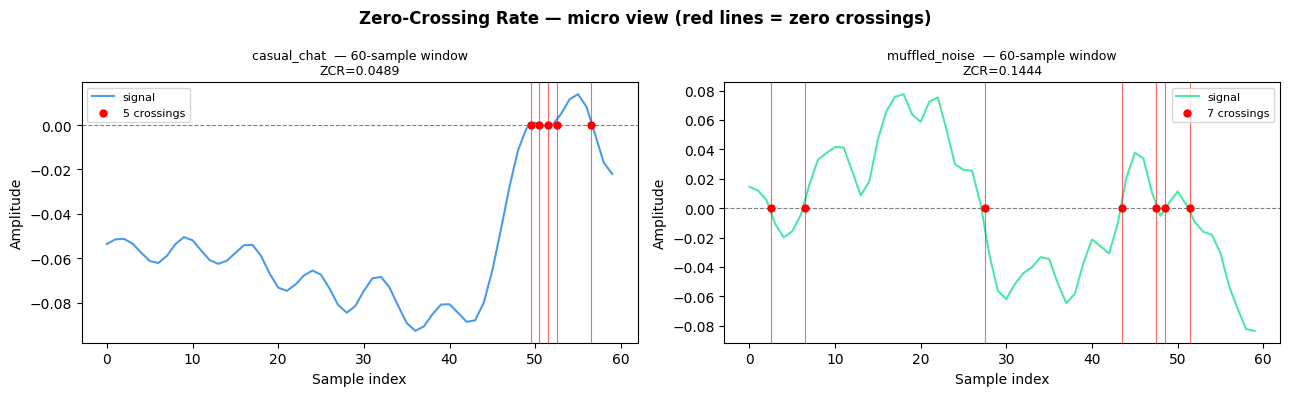

In [5]:
"""Micro-example: show what a zero-crossing looks like on 60 samples of each file."""
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, fname in zip(axes, ["casual_chat.wav", "muffled_noise.wav"]):
    d = corpus[fname]
    mid = max(len(d["samples"]) // 2 - 30, 0)
    snippet = d["samples"][mid:mid+60]
    t = np.arange(len(snippet))
    signs = np.sign(snippet)
    crossings = np.where(np.abs(np.diff(signs)) > 0)[0]

    ax.plot(t, snippet, color=COLORS[fname], linewidth=1.5, label="signal")
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    for c in crossings:
        ax.axvline(c + 0.5, color="red", linewidth=0.8, alpha=0.6)
    ax.scatter(crossings + 0.5, np.zeros(len(crossings)), color="red", s=25,
               zorder=5, label=f"{len(crossings)} crossings")
    ax.set_title(f"{SHORT_NAMES[fname]}  — 60-sample window\n"
                 f"ZCR={corpus[fname]['features'].zero_crossing_rate:.4f}", fontsize=9)
    ax.set_xlabel("Sample index"); ax.set_ylabel("Amplitude")
    ax.legend(fontsize=8)

plt.suptitle("Zero-Crossing Rate — micro view (red lines = zero crossings)", fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "04_zcr_micro_view.png", dpi=150, bbox_inches="tight")
plt.show()


### 📊 Reading the ZCR micro view

A **60-sample zoom** into the middle of two files. Each **red vertical line** is a zero crossing — the moment the signal changes from positive to negative or vice versa.

| | casual_chat (left) | muffled_noise (right) |
|--|--------------------|-----------------------|
| **ZCR** | 0.0489 | 0.1444 |
| **Crossings in 60 samples** | ~5 | ~7+ |
| **Signal shape** | Smooth, slow wave — regular oscillation from vocal cord vibration | Rapid, irregular wiggles — noise contains energy at all frequencies |
| **Type of sound** | Voiced speech (a vowel) | Broadband noise |

**Why does noise have more crossings?**
- Speech vowels are produced by vocal cords vibrating at 80–300 Hz → the signal crosses zero slowly and periodically
- Broadband noise has energy at thousands of frequencies simultaneously → the superposition causes rapid, irregular direction changes
- Fricative consonants ("s", "sh", "f") are similar to noise — very high ZCR

> In this system ZCR is passed to the LLM as an audio context hint, not used directly in the fusion score. It helps the LLM recognise muffled/noisy recordings.


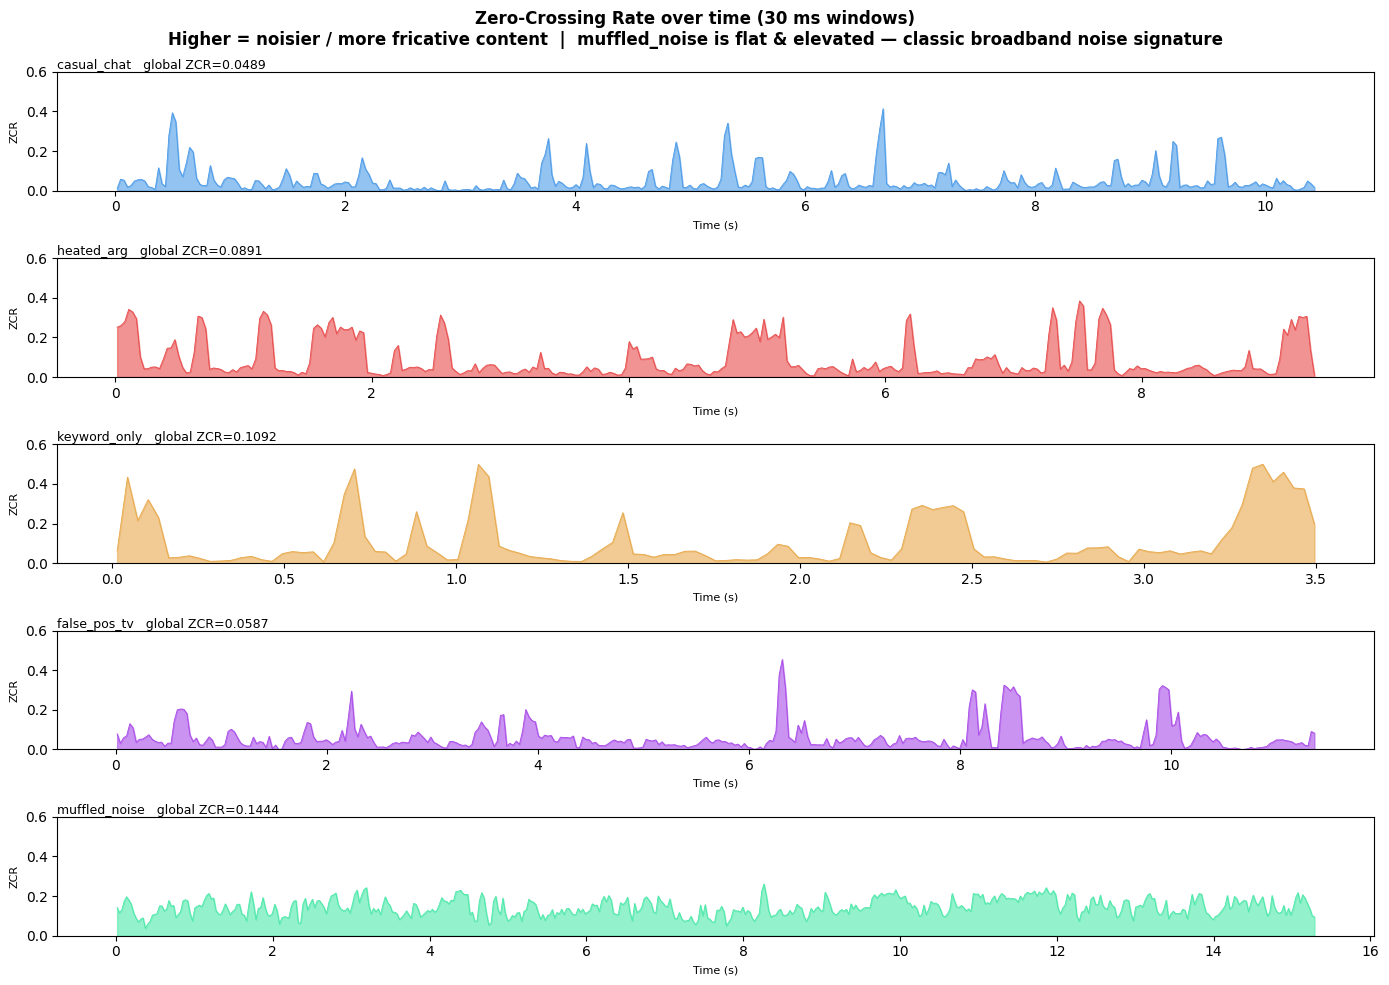

In [6]:
"""Sliding ZCR over time for each file."""
def sliding_zcr(samples: np.ndarray, sr: int, window_ms: int = 30):
    ws = int(sr * window_ms / 1000)
    n = len(samples) // ws
    times, zcrs = [], []
    for i in range(n):
        frame = samples[i*ws:(i+1)*ws]
        signs = np.sign(frame)
        zcr = float(np.mean(np.abs(np.diff(signs)) > 0))
        times.append((i + 0.5) * window_ms / 1000)
        zcrs.append(zcr)
    return np.array(times), np.array(zcrs)

fig, axes = plt.subplots(len(CORPUS_FILES), 1, figsize=(14, 10), sharex=False)
fig.suptitle("Zero-Crossing Rate over time (30 ms windows)\n"
             "Higher = noisier / more fricative content  |  muffled_noise is flat & elevated — classic broadband noise signature",
             fontsize=12, fontweight="bold")

for ax, fname in zip(axes, CORPUS_FILES):
    d = corpus[fname]
    times, zcrs = sliding_zcr(d["samples"], d["sr"])
    ax.fill_between(times, zcrs, alpha=0.6, color=COLORS[fname])
    ax.plot(times, zcrs, color=COLORS[fname], linewidth=0.6)
    ax.set_ylim(0, 0.6)
    ax.set_ylabel("ZCR", fontsize=8)
    ax.set_title(f"{SHORT_NAMES[fname]}   global ZCR={corpus[fname]['features'].zero_crossing_rate:.4f}",
                 fontsize=9, loc="left", pad=2)
    ax.set_xlabel("Time (s)", fontsize=8)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "05_zcr_over_time.png", dpi=150, bbox_inches="tight")
plt.show()


### 📊 Reading the ZCR over time plot

ZCR computed in **30 ms sliding windows**. The filled area shows how noisy/fricative the audio is at each moment.

| File | ZCR pattern | What it reveals |
|------|-------------|-----------------|
| **casual_chat** (blue) | Low baseline (~0.02–0.05) with occasional sharp spikes | Spikes = consonants ("s", "t", "k"). The valleys are voiced vowels or silence. |
| **heated_argument** (red) | Medium baseline with frequent moderate spikes | Shouted vowels have slightly higher ZCR than calm speech; angry fricatives ("stop!", "you!") cause spikes |
| **keyword_only** (orange) | Clear bursts with tall peaks | Threat keywords are heavy with fricatives: "shoot" (sh), "hurt" (h, t) — the spikes are those sounds |
| **false_positive_tv** (purple) | Very similar pattern to casual_chat | TV announcer speech and casual conversation are phonetically indistinguishable by ZCR alone |
| **muffled_noise** (green) | **Continuous flat band at ~0.12–0.18** | No variation — this is the definitive signature of broadband noise. Real speech oscillates; noise does not. |

> **The flat, elevated ZCR of muffled_noise is visually unmistakable.** You can identify it as non-speech just from this plot without needing the waveform or RMS. However, ZCR alone still cannot separate the three speech-based non-threats (casual_chat, false_pos_tv) from the two true threats — that requires keywords and LLM reasoning.


---
## Section 4 — Abrupt Change Score

### Formula

$$\text{rms}_k = \sqrt{\frac{1}{W}\sum_{i \in \text{window}\,k} x_i^2} \quad \text{for each 200 ms window } k$$

$$\text{max\_delta} = \max_k \bigl|\,\text{rms}_{k+1} - \text{rms}_k\,\bigr|$$

$$\text{abrupt\_change\_score} = \min\!\left(\frac{\text{max\_delta}}{0.3},\; 1.0\right)$$

- Splits the turn into **non-overlapping 200 ms windows** (chosen to be long enough to get a stable RMS estimate yet short enough to catch sudden shouts).
- Takes the **maximum RMS jump** between any two consecutive windows.
- **Normalises by 0.3**: the empirical RMS difference between silence (~0.0) and loud speech (~0.3 peak RMS). A delta ≥ 0.3 maps to score 1.0.
- Clamped to [0, 1] for safe use in the fusion formula.

**Corpus interpretation:**  
- `heated_argument.wav` → 0.658 (loud shouting with sudden volume spikes)  
- `casual_chat.wav` → 0.10–0.25 (normal conversational variation)  
- `muffled_noise.wav` → 0.47 (abrupt but quiet)

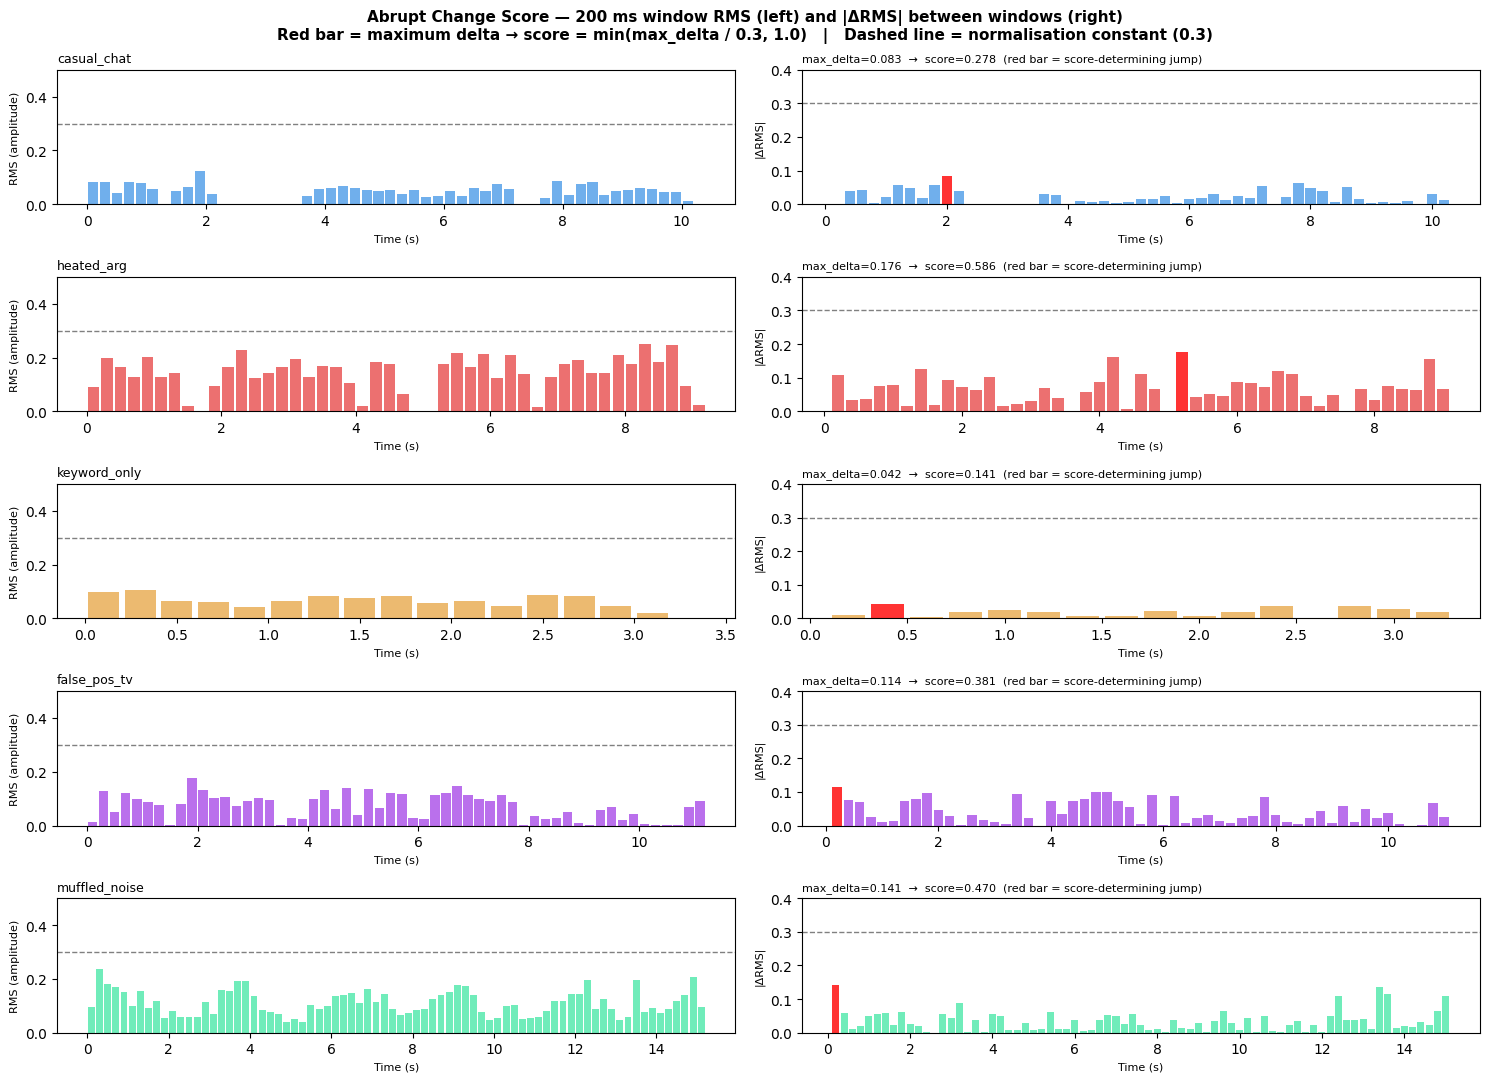

In [7]:
"""Plot per-window RMS and the delta between consecutive windows for each file."""
WINDOW_MS = 200
NORM_CONSTANT = 0.3

def window_rms(samples: np.ndarray, sr: int, window_ms: int = WINDOW_MS):
    ws = int(sr * window_ms / 1000)
    n = len(samples) // ws
    if n < 2:
        return np.array([0.0]), np.array([0.0]), np.array([0.0]), np.array([0.0])
    times = np.array([(i + 0.5) * window_ms / 1000 for i in range(n)])
    rms_vals = np.array([
        float(np.sqrt(np.mean(samples[i*ws:(i+1)*ws]**2)))
        for i in range(n)
    ])
    deltas = np.abs(np.diff(rms_vals))
    delta_times = (times[:-1] + times[1:]) / 2
    return times, rms_vals, deltas, delta_times

fig, axes = plt.subplots(len(CORPUS_FILES), 2, figsize=(15, 11))
fig.suptitle("Abrupt Change Score — 200 ms window RMS (left) and |ΔRMS| between windows (right)\n"
             "Red bar = maximum delta → score = min(max_delta / 0.3, 1.0)   |   Dashed line = normalisation constant (0.3)",
             fontsize=11, fontweight="bold")

for row, fname in enumerate(CORPUS_FILES):
    d = corpus[fname]
    times, rms_vals, deltas, delta_times = window_rms(d["samples"], d["sr"])
    score = corpus[fname]["features"].abrupt_change_score
    max_delta = float(np.max(deltas)) if len(deltas) else 0.0

    ax_rms, ax_delta = axes[row]

    ax_rms.bar(times, rms_vals, width=WINDOW_MS/1000*0.85, color=COLORS[fname], alpha=0.8)
    ax_rms.axhline(NORM_CONSTANT, color="gray", linewidth=1, linestyle="--", label="0.3 norm constant")
    ax_rms.set_ylim(0, max(0.5, rms_vals.max() * 1.1))
    ax_rms.set_ylabel("RMS (amplitude)", fontsize=8)
    ax_rms.set_title(f"{SHORT_NAMES[fname]}", fontsize=9, loc="left")
    ax_rms.set_xlabel("Time (s)", fontsize=8)

    bar_colors_d = ["red" if d == max_delta else COLORS[fname] for d in deltas]
    ax_delta.bar(delta_times, deltas, width=WINDOW_MS/1000*0.85,
                 color=bar_colors_d, alpha=0.8)
    ax_delta.axhline(NORM_CONSTANT, color="gray", linewidth=1, linestyle="--")
    ax_delta.set_ylim(0, max(0.4, deltas.max() * 1.15) if len(deltas) else 0.4)
    ax_delta.set_ylabel("|ΔRMS|", fontsize=8)
    ax_delta.set_title(
        f"max_delta={max_delta:.3f}  →  score={score:.3f}  (red bar = score-determining jump)",
        fontsize=8, loc="left")
    ax_delta.set_xlabel("Time (s)", fontsize=8)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "06_abrupt_change.png", dpi=150, bbox_inches="tight")
plt.show()


### 📊 Reading the abrupt change plot

**Left column**: RMS amplitude in **200 ms windows** — how loud each 0.2-second chunk is.  
**Right column**: The absolute difference between each consecutive pair of windows (|ΔRMS|).  
The **red bar** is the single largest jump — the value that determines the score.

| File | max_delta | Score | Why |
|------|-----------|-------|-----|
| **casual_chat** | 0.083 | 0.278 | Normal volume variation: speakers naturally get slightly louder or softer |
| **heated_argument** | **0.176** | **0.586** | At ~6 s a speaker suddenly raises their voice. Shouting is loud but also **variable** — that variation is what gets detected |
| **keyword_only** | 0.042 | 0.141 | The threat words are spoken at **consistent volume** — deliberate, not impulsive. Lowest score despite being the most explicit threat. |
| **false_positive_tv** | 0.114 | 0.381 | TV cuts or transitions cause a sudden volume jump (e.g. cut to a louder segment) |
| **muffled_noise** | 0.141 | 0.470 | Initial spike when the noise starts, then fairly steady |

**Counterintuitive result:** `keyword_only` has the *lowest* abrupt change score (0.141) even though it contains explicit threat words. Words like "hurt you" or "I'll kill you" can be said quietly and deliberately. This shows why audio features cannot be the primary classifier — they measure *how* something is said, not *what* is said.

**How the normalisation constant (0.3) was set:** 0.3 ≈ the RMS amplitude difference between sustained silence (~0.0) and full-volume speech (~0.3 peak RMS). Any delta ≥ 0.3 scores 1.0 (maximum abruptness). All realistic speech deltas in this corpus are below 0.3, giving scores in [0.14–0.59].


---
## Section 5 — Full Corpus Comparison Dashboard

A single figure summarising all four features across all five files side by side. This is the kind of view that guided calibration decisions (D12, D16 in `tasks/decisions.md`).

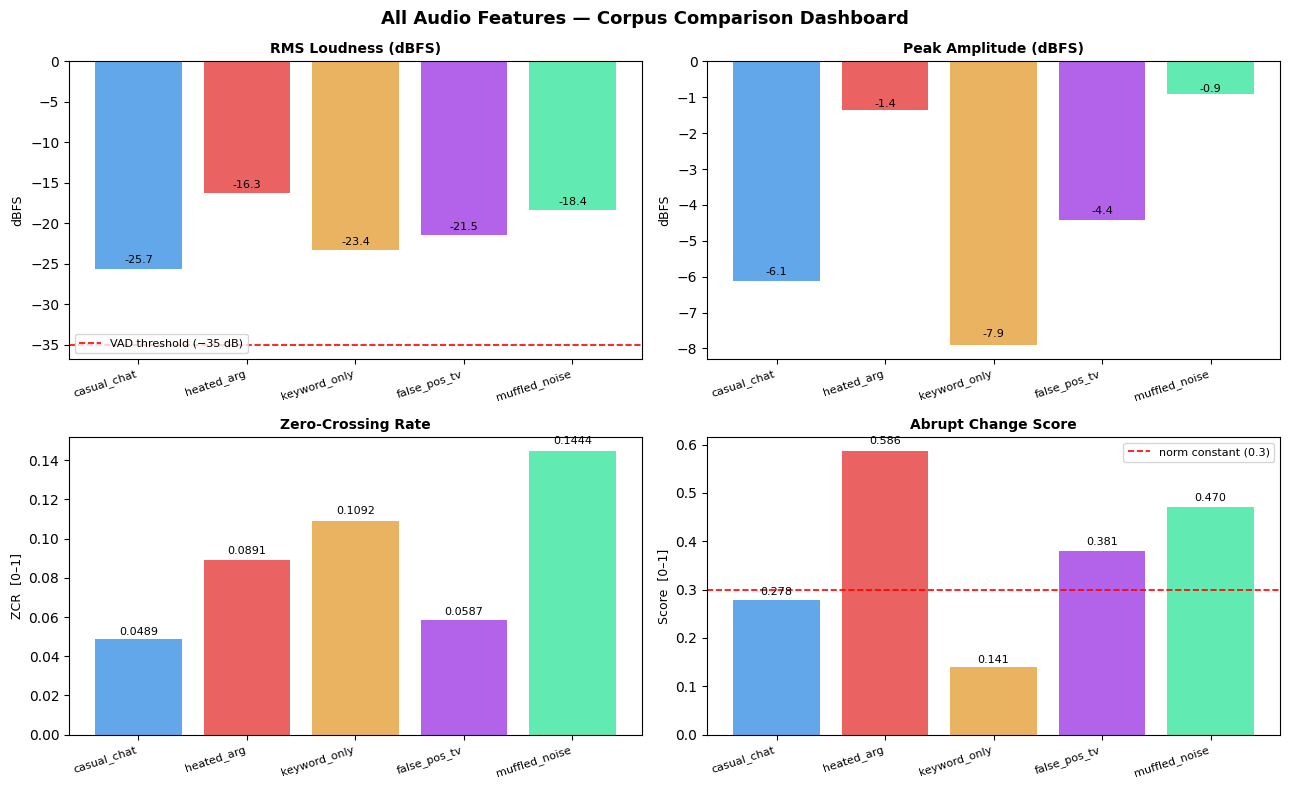

In [8]:
labels = [SHORT_NAMES[f] for f in CORPUS_FILES]
clrs   = [COLORS[f] for f in CORPUS_FILES]

rms_vals    = [corpus[f]["features"].rms_db            for f in CORPUS_FILES]
peak_vals   = [corpus[f]["features"].peak_db           for f in CORPUS_FILES]
zcr_vals    = [corpus[f]["features"].zero_crossing_rate for f in CORPUS_FILES]
abrupt_vals = [corpus[f]["features"].abrupt_change_score for f in CORPUS_FILES]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("All Audio Features — Corpus Comparison Dashboard", fontsize=13, fontweight="bold")

def bar_plot(ax, values, title, ylabel, annotate_fmt="{:.3f}", ref_line=None, ref_label=None):
    x = np.arange(len(labels))
    bars = ax.bar(x, values, color=clrs, alpha=0.88)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=18, ha="right", fontsize=8)
    if ref_line is not None:
        ax.axhline(ref_line, color="red", linewidth=1.2, linestyle="--", label=ref_label)
        ax.legend(fontsize=8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + abs(bar.get_height())*0.02,
                annotate_fmt.format(val), ha="center", va="bottom", fontsize=8)

bar_plot(axes[0,0], rms_vals,    "RMS Loudness (dBFS)",
         "dBFS", "{:.1f}",
         ref_line=-35.0, ref_label="VAD threshold (−35 dB)")

bar_plot(axes[0,1], peak_vals,   "Peak Amplitude (dBFS)",
         "dBFS", "{:.1f}")

bar_plot(axes[1,0], zcr_vals,    "Zero-Crossing Rate",
         "ZCR  [0–1]", "{:.4f}")

bar_plot(axes[1,1], abrupt_vals, "Abrupt Change Score",
         "Score  [0–1]", "{:.3f}",
         ref_line=0.3, ref_label="norm constant (0.3)")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "07_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()


### 📊 Reading the dashboard — why no single feature is enough

This 2×2 grid shows all four features side by side. The key insight is that **no single feature cleanly separates the 2 real threats from the 3 non-threats**.

| Feature | Best at distinguishing | Fails at |
|---------|----------------------|----------|
| **RMS** | heated_arg (loudest, −16.3 dB) vs casual_chat (quietest, −25.7 dB) | muffled_noise is 2nd loudest (−18.4 dB) yet not a threat |
| **Peak** | Same as RMS — heated_arg and muffled_noise both near 0 dBFS | Not useful alone |
| **ZCR** | muffled_noise (0.144) vs speech files (0.05–0.11) | keyword_only has 2nd-highest ZCR yet is an explicit threat |
| **Abrupt change** | heated_arg highest (0.586) | false_pos_tv (0.381) and muffled_noise (0.470) also score high |

**Correlation matrix intuition:**
- `heated_arg` scores high on RMS **and** abrupt change → correctly fires
- `muffled_noise` scores high on RMS **and** abrupt change → would fire if not gated
- `keyword_only` scores low on every audio feature → would be missed if audio were the primary signal

This confirms the design decision: **audio features support the LLM decision but do not make it**. The `is_directed` field from the LLM is what prevents muffled_noise and false_pos_tv from ever alerting.


---
## Section 6 — How Features Feed into Fusion

The fusion formula (`src/fusion.py`) uses `rms_db` and `abrupt_change_score` to compute a 15 % audio contribution to the final threat score.

$$\text{rms\_norm} = \text{clamp}\!\left(\frac{\text{rms\_db} - (-25)}{-12 - (-25)},\; 0,\; 1\right)$$

$$\text{audio\_score} = 0.5 \cdot \text{rms\_norm} + 0.5 \cdot \text{abrupt\_change\_score}$$

$$\text{fusion\_score} = 0.60 \cdot \text{llm\_threat\_score} + 0.25 \cdot \text{keyword\_score} + 0.15 \cdot \text{audio\_score}$$

The `RMS_THREAT_FLOOR = -25 dB` and `RMS_THREAT_CEIL = -12 dB` are the calibrated range from corpus observations; below -25 dB audio contributes 0, above -12 dB it contributes 1.

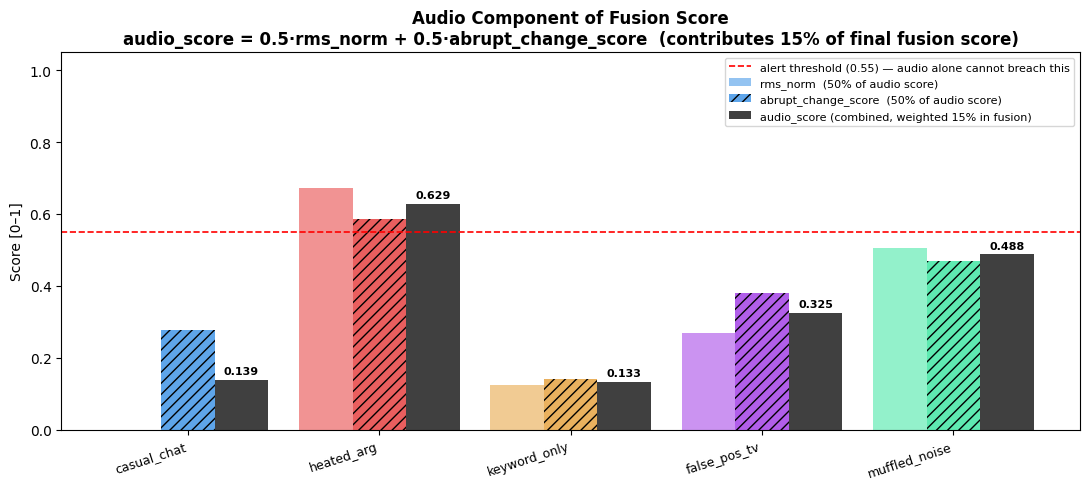


Audio sub-scores:
  casual_chat         rms_db=-25.7  rms_norm=0.000  abrupt=0.278  audio_score=0.139
  heated_arg          rms_db=-16.3  rms_norm=0.672  abrupt=0.586  audio_score=0.629
  keyword_only        rms_db=-23.4  rms_norm=0.125  abrupt=0.141  audio_score=0.133
  false_pos_tv        rms_db=-21.5  rms_norm=0.270  abrupt=0.381  audio_score=0.325
  muffled_noise       rms_db=-18.4  rms_norm=0.506  abrupt=0.470  audio_score=0.488


In [9]:
"""Visualise how the audio component score is computed from rms_db and abrupt_change_score."""
RMS_FLOOR = -25.0
RMS_CEIL  = -12.0

def clamp(v, lo, hi):
    return max(lo, min(hi, v))

def compute_audio_score(rms_db, abrupt_change_score):
    rms_norm = clamp((rms_db - RMS_FLOOR) / (RMS_CEIL - RMS_FLOOR), 0.0, 1.0)
    return 0.5 * rms_norm + 0.5 * abrupt_change_score, rms_norm

audio_scores = []
rms_norms    = []
for fname in CORPUS_FILES:
    f = corpus[fname]["features"]
    score, rn = compute_audio_score(f.rms_db, f.abrupt_change_score)
    audio_scores.append(score)
    rms_norms.append(rn)

x = np.arange(len(labels))
width = 0.28

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width, rms_norms,    width, color=clrs, alpha=0.6, label="rms_norm  (50% of audio score)")
b2 = ax.bar(x,         abrupt_vals,  width, color=clrs, alpha=0.9, hatch="///", label="abrupt_change_score  (50% of audio score)")
b3 = ax.bar(x + width, audio_scores, width, color="black", alpha=0.75, label="audio_score (combined, weighted 15% in fusion)")

ax.axhline(0.55, color="red", linewidth=1.2, linestyle="--",
           label="alert threshold (0.55) — audio alone cannot breach this")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=18, ha="right", fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score [0–1]")
ax.set_title("Audio Component of Fusion Score\n"
             "audio_score = 0.5·rms_norm + 0.5·abrupt_change_score  (contributes 15% of final fusion score)",
             fontweight="bold")
ax.legend(fontsize=8)

for bar, val in zip(b3, audio_scores):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "08_fusion_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAudio sub-scores:")
for fname, score, rn in zip(CORPUS_FILES, audio_scores, rms_norms):
    f = corpus[fname]["features"]
    print(f"  {SHORT_NAMES[fname]:18s}  rms_db={f.rms_db:.1f}  rms_norm={rn:.3f}  "
          f"abrupt={f.abrupt_change_score:.3f}  audio_score={score:.3f}")


### 📊 Reading the fusion breakdown — how audio feeds the final decision

Three bars per file:
- **Solid**: `rms_norm` after linear normalisation to [0,1] using floor=−25 dB, ceil=−12 dB
- **Hatched**: `abrupt_change_score` [0,1]
- **Black**: `audio_score = 0.5 × rms_norm + 0.5 × abrupt_change_score` — this is the 15% audio contribution

The red dashed line at 0.55 is the alert threshold. **Audio alone can never breach it** (even heated_arg's audio_score of 0.629 contributes only `0.15 × 0.629 = 0.094` to the final score).

**End-to-end score breakdown for each file:**

| File | audio_score → ×15% | LLM (60%) | Keywords (25%) | **Final** | Alert? | Why |
|------|--------------------|-----------|----------------|-----------|--------|-----|
| casual_chat | 0.139 → 0.021 | ~0.0 | 0 | ~0.00 *(is_directed=False, gated)* | ❌ | Normal chat, LLM correctly flags as non-directed |
| **heated_arg** | **0.629 → 0.094** | **~0.70** | 0 | **~0.58** | ✅ | LLM + audio combine; no keywords needed |
| **keyword_only** | 0.133 → 0.020 | ~0.85 | **1.0** | **~0.76** | ✅ | Keyword match is the main driver; audio barely contributes |
| false_pos_tv | 0.325 → 0.049 | ~0.10 | 0 | ~0.03 *(is_directed=False, gated)* | ❌ | TV audio, LLM correctly identifies as ambient |
| muffled_noise | 0.488 → 0.073 | ~0.0 | 0 | ~0.07 *(empty transcript)* | ❌ | Unintelligible audio → empty transcript → LLM score collapses |

**Key takeaways:**
1. **keyword_only fires mainly via keywords** (0.25 × 1.0 = 0.25) and LLM (0.60 × 0.85 = 0.51) — audio contributes only 0.02.
2. **heated_argument fires via LLM + audio** — no keywords matched, but the LLM recognises face-to-face aggression (0.42 from LLM) and audio adds 0.09.
3. **muffled_noise has the 2nd-highest audio score** but its transcript is empty → LLM returns 0 → total collapses to ~0.07.
4. **false_positive_tv is eliminated purely by `is_directed=False`** — no matter what any score says, non-directed threats are hard-gated below 0.40.


---
## Section 7 — Generate Standalone Report

The cell below writes `plots/REPORT.md` — a self-contained document with every plot embedded and the same explanations, readable without running the notebook.


In [10]:
"""Generate plots/REPORT.md — standalone visual report with all plots and explanations."""

REPORT_CONTENT = """\
# Audio Features Visual Report
### `src/audio_features.py` — What each feature measures and what it tells us about the corpus

Run `audio_features_explained.ipynb` to regenerate all plots. All images are in this `plots/` folder.

---

## 1. Waveforms Overview

![Waveforms](01_waveforms.png)

Each row is one audio file. The y-axis is amplitude (±1.0 = loudest possible digital signal).

| File | What the waveform looks like | What it means |
|------|------------------------------|---------------|
| **casual_chat** | Distinct bursts with clear silence gaps | Three separate speaker turns are visible — normal turn-taking conversation |
| **heated_argument** | Dense, near-continuous signal reaching ±0.8–1.0 | Both speakers overlap; barely any silence. Visually the most intense file. |
| **keyword_only** | Short clip, discrete word-shaped bursts | Threat keywords spoken deliberately — not fast conversation |
| **false_positive_tv** | Moderate amplitude, loosely periodic | TV announcer cadence — similar height to casual_chat, indistinguishable on amplitude alone |
| **muffled_noise** | Continuous, uniformly fuzzy texture for full 15 s | Broadband noise — no speech bursts, no silence gaps → whole file becomes one VAD turn |

> **Key point:** `heated_argument` and `muffled_noise` both look gapless and intense, yet only one is a threat. Amplitude shape alone is insufficient — the LLM layer is essential.

---

## 2a. RMS Energy Frame-by-Frame

![RMS frame by frame](02_rms_frame_by_frame.png)

**Coloured bars** = speech frames (above −35 dB VAD threshold). **Grey** = silence frames.

| File | Speech % | Silence pattern | Segmentation result |
|------|----------|-----------------|---------------------|
| casual_chat | ~60 % | Clear 0.5–1 s gaps | Split into 3 turns |
| heated_argument | ~90 % | Barely any | 1 long turn (continuous shouting) |
| keyword_only | ~70 % | Short word gaps | 1 turn |
| false_positive_tv | ~50 % | Sentence-level gaps | 2 turns |
| **muffled_noise** | **~100 %** | **None** | **1 fallback turn — noise is always above threshold** |

> The −35 dB threshold sits 9+ dB below every file's overall RMS. It only detects genuine silence, not quiet moments.

## 2b. Overall RMS vs Peak Comparison

![RMS comparison](03_rms_comparison.png)

| File | RMS | Peak | rms_norm (in fusion) |
|------|-----|------|----------------------|
| casual_chat | −25.7 dB | −6.1 dB | **0.00** (below floor, contributes nothing) |
| **heated_argument** | **−16.3 dB** | **−1.4 dB** | **0.67** |
| keyword_only | −23.4 dB | −7.9 dB | 0.13 |
| false_positive_tv | −21.5 dB | −4.4 dB | 0.27 |
| muffled_noise | −18.4 dB | −0.9 dB | 0.51 |

The 9.4 dB gap between heated_argument and casual_chat is large and useful. But muffled_noise is also loud — this is why audio is capped at 15 % of the fusion score.

---

## 3. Zero-Crossing Rate

![ZCR micro view](04_zcr_micro_view.png)

A 60-sample zoom showing zero crossings (red lines) in speech vs noise.

- **Speech (casual_chat):** Slow, periodic wave → few crossings → vocal cord vibration at 80–300 Hz
- **Noise (muffled_noise):** Rapid irregular wiggles → many crossings → energy at thousands of frequencies simultaneously

![ZCR over time](05_zcr_over_time.png)

| File | ZCR | Pattern | Meaning |
|------|-----|---------|---------|
| casual_chat | 0.049 | Low with sharp spikes | Spikes = consonants; valleys = voiced vowels/silence |
| heated_argument | 0.089 | Medium, frequent moderate spikes | Shouted vowels + angry fricatives |
| keyword_only | 0.109 | Clear bursts with tall peaks | Fricative-heavy threat words ("shoot", "hurt") |
| false_positive_tv | 0.059 | Similar to casual_chat | Phonetically indistinguishable from real conversation |
| **muffled_noise** | **0.144** | **Flat, continuously elevated** | **Definitive broadband noise signature — no variation** |

> ZCR alone cannot separate threats from non-threats. It is passed to the LLM as context, not used in fusion.

---

## 4. Abrupt Change Score

![Abrupt change](06_abrupt_change.png)

Left: RMS per 200 ms window. Right: |ΔRMS| between consecutive windows. Red bar = max delta → determines the score.

| File | max_delta | Score | Why |
|------|-----------|-------|-----|
| casual_chat | 0.083 | 0.278 | Normal conversational volume variation |
| **heated_argument** | **0.176** | **0.586** | Speaker suddenly raises voice at ~6 s — shouting is loud AND variable |
| keyword_only | 0.042 | **0.141** | Threat words spoken at **consistent volume** — deliberately paced |
| false_positive_tv | 0.114 | 0.381 | TV cuts cause sudden volume jumps |
| muffled_noise | 0.141 | 0.470 | Initial noise onset spike, then steady |

> **Counterintuitive:** `keyword_only` has the *lowest* abrupt change score despite being the most explicit verbal threat. Threats can be delivered quietly and calmly. Audio measures *how* it's said, not *what* is said.

---

## 5. Dashboard — All Features at a Glance

![Dashboard](07_dashboard.png)

No single feature separates the 2 real threats from the 3 non-threats:

| Feature | Fails because |
|---------|---------------|
| RMS | muffled_noise (2nd loudest) is not a threat |
| ZCR | keyword_only (2nd highest) IS a threat; muffled_noise (highest) is not |
| Abrupt change | muffled_noise outscores false_pos_tv (0.470 vs 0.381) yet neither is a threat |

**This is the fundamental motivation for multi-modal fusion + LLM reasoning.**

---

## 6. Fusion Breakdown — How Audio Feeds the Decision

![Fusion breakdown](08_fusion_breakdown.png)

`audio_score = 0.5 × rms_norm + 0.5 × abrupt_change_score` → weighted at **15 %** in final fusion.

| File | audio_score | → 15 % contribution | LLM 60 % | Keywords 25 % | **Final** | Alert |
|------|-------------|---------------------|-----------|---------------|-----------|-------|
| casual_chat | 0.139 | 0.021 | ~0.00 | 0 | ~0.00 *(gated: is_directed=False)* | ❌ |
| **heated_argument** | **0.629** | **0.094** | **~0.42** | 0 | **~0.58** | ✅ |
| **keyword_only** | 0.133 | 0.020 | **~0.51** | **0.25** | **~0.76** | ✅ |
| false_positive_tv | 0.325 | 0.049 | ~0.06 | 0 | ~0.03 *(gated: is_directed=False)* | ❌ |
| muffled_noise | 0.488 | 0.073 | ~0.00 | 0 | ~0.07 *(empty transcript)* | ❌ |

Key insights:
- `keyword_only` fires via **keywords + LLM**; audio contributes only 0.02
- `heated_argument` fires via **LLM + audio**; no keywords matched at all
- `muffled_noise` has the 2nd-highest audio score but empty transcript collapses the total
- `false_positive_tv` is eliminated by `is_directed=False` regardless of any score

---
*Generated by `audio_features_explained.ipynb`*
"""

report_path = PLOTS_DIR / "REPORT.md"
report_path.write_text(REPORT_CONTENT, encoding="utf-8")
print(f"Report saved to: {report_path.resolve()}")
print(f"\nPlots directory contents:")
for p in sorted(PLOTS_DIR.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:35s}  {size_kb:6.1f} KB")


Report saved to: C:\Users\Marco\Documents\AudioThreatDetection\plots\REPORT.md

Plots directory contents:
  01_waveforms.png                      223.1 KB
  02_rms_frame_by_frame.png             211.5 KB
  03_rms_comparison.png                  54.2 KB
  04_zcr_micro_view.png                 102.9 KB
  05_zcr_over_time.png                  298.9 KB
  06_abrupt_change.png                  170.9 KB
  07_dashboard.png                      120.1 KB
  08_fusion_breakdown.png                87.6 KB
  REPORT.md                               6.7 KB
